In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from mpralib.mpradata import MPRABarcodeData
from mpralib.mpradata import Modality
from mpralib.utils.plot import dna_vs_rna, barcodes_per_oligo
from mpralib.utils.plot import correlation
from mpralib.mpradata import BarcodeFilter
from mpralib.utils.io import export_activity_file
from mpralib.utils.io import export_barcode_file
from scipy.stats import spearmanr, pearsonr
from copy import deepcopy

# Element Barcode Filter Notebook

### Load MPRAsnakeflow table

In [109]:
df_NGN2 = pd.read_table('data/reporter_experiment.barcode.NGN2.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')
df_WTC11 = pd.read_table('data/reporter_experiment.barcode.WTC11.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')

In [110]:
def threshold_filter(
        data_table: pd.DataFrame,
        threshold: int = 10
        ):
        barcode_count = (
        data_table.groupby('oligo_name')['barcode']
        .transform('nunique')
        )

        df_filtered = data_table[barcode_count >= threshold].copy()
        return df_filtered

In [6]:
NGN2_bc_50 =threshold_filter(data_table = df_NGN2,
                 threshold = 50)
NGN2_bc_50.to_csv('data/results/barcode_thresholds/NGN2_bc_50.tsv.gz',
                  sep = '\t',
                  index = False)

WTC11_bc_50 =threshold_filter(data_table = df_WTC11,
                 threshold = 50)
WTC11_bc_50.to_csv('data/results/barcode_thresholds/WTC11_bc_50.tsv.gz',
                   sep = '\t',
                   index = False)

NGN2_bc_10 =threshold_filter(data_table = df_NGN2,
                 threshold = 10)
NGN2_bc_10.to_csv('data/results/barcode_thresholds/NGN2_bc_10.tsv.gz',
                   sep = '\t',
                   index = False)

WTC11_bc_10 =threshold_filter(data_table = df_WTC11,
                 threshold = 10)
WTC11_bc_10.to_csv('data/results/barcode_thresholds/WTC11_bc_10.tsv.gz',
                   sep = '\t',
                   index = False)

NGN2_bc_20 =threshold_filter(data_table = df_NGN2,
                 threshold = 20)
NGN2_bc_20.to_csv('data/results/barcode_thresholds/NGN2_bc_20.tsv.gz',
                   sep = '\t',
                   index = False)

WTC11_bc_20 =threshold_filter(data_table = df_WTC11,
                 threshold = 20)
WTC11_bc_20.to_csv('data/results/barcode_thresholds/WTC11_bc_20.tsv.gz',
                   sep = '\t',
                   index = False)

### Load MPRAsnakeflow data in MPRAlib

In [3]:
element_unfiltered_NGN2_bc_10 = MPRABarcodeData.from_file('data/results/barcode_thresholds/NGN2_bc_10.tsv.gz')
element_unfiltered_WTC11_bc_10 = MPRABarcodeData.from_file('data/results/barcode_thresholds/WTC11_bc_10.tsv.gz')
element_unfiltered_NGN2_bc_20 = MPRABarcodeData.from_file('data/results/barcode_thresholds/NGN2_bc_20.tsv.gz')
element_unfiltered_WTC11_bc_20 = MPRABarcodeData.from_file('data/results/barcode_thresholds/WTC11_bc_20.tsv.gz')
element_unfiltered_NGN2_bc_50 = MPRABarcodeData.from_file('data/results/barcode_thresholds/NGN2_bc_50.tsv.gz')
element_unfiltered_WTC11_bc_50 = MPRABarcodeData.from_file('data/results/barcode_thresholds/WTC11_bc_50.tsv.gz')

In [111]:
element_unfiltered_NGN2 = MPRABarcodeData.from_file('data/reporter_experiment.barcode.NGN2.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')
element_unfiltered_WTC11 = MPRABarcodeData.from_file('data/reporter_experiment.barcode.WTC11.bbmapMapq30StrandSensitiveAssignment.default.all.tsv.gz')

### Load the merged and enhanced Element data (its a combination from the MPRAsnakeflow data with the Bcalm data combined over the given celltypes)

In [5]:
element_merge = pd.read_table('data/results/merge_elements/element_merge.tsv.gz')

In [20]:
def barcode_filter(
    element_unfiltered: MPRABarcodeData,
    z_score: int = 3,
    threshold: int = 10
) -> MPRABarcodeData:

    element_filtered = deepcopy(element_unfiltered)
    element_filtered.var_filter = None

    element_filtered.barcode_threshold = threshold
    element_filtered.apply_barcode_filter(
    BarcodeFilter.MIN_BCS_PER_OLIGO,
    {"threshold": threshold}
)
    element_filtered.apply_barcode_filter(
        BarcodeFilter.OLIGO_SPECIFIC,
        {"times_zscore": z_score,
        "apply_bc_threshold": True
         })

    
    return element_filtered



### Z-score test

In [5]:
NGN2_filtered_bc_10_z_3 = barcode_filter(element_unfiltered = element_unfiltered_NGN2_bc_10,
                                         threshold = 0)
NGN2_filtered_bc_50_z_3 = barcode_filter(element_unfiltered = element_unfiltered_NGN2_bc_50,
                                         threshold = 0)
WTC11_filtered_bc_10_z_3 = barcode_filter(element_unfiltered = element_unfiltered_WTC11_bc_10,
                                          threshold = 0)
WTC11_filtered_bc_50_z_3 = barcode_filter(element_unfiltered = element_unfiltered_WTC11_bc_50,
                                          threshold = 0)


In [112]:
NGN2_filtered_bc_10_z_3 = barcode_filter(element_unfiltered = element_unfiltered_NGN2,)
NGN2_filtered_bc_50_z_3 = barcode_filter(element_unfiltered = element_unfiltered_NGN2,
                                         threshold = 50)
WTC11_filtered_bc_10_z_3 = barcode_filter(element_unfiltered = element_unfiltered_WTC11)
WTC11_filtered_bc_50_z_3 = barcode_filter(element_unfiltered = element_unfiltered_WTC11,
                                          threshold = 50)


In [6]:
NGN2_filtered_bc_10_z_2 = barcode_filter(element_unfiltered = element_unfiltered_NGN2,
                                         z_score = 2)
NGN2_filtered_bc_50_z_2 = barcode_filter(element_unfiltered = element_unfiltered_NGN2,
                                         threshold = 50,
                                         z_score = 2)
WTC11_filtered_bc_10_z_2 = barcode_filter(element_unfiltered = element_unfiltered_WTC11,
                                          z_score = 2)
WTC11_filtered_bc_50_z_2 = barcode_filter(element_unfiltered = element_unfiltered_WTC11,
                                          threshold = 50,
                                          z_score = 2)


In [113]:
NGN2_filtered_bc_10_z_1 = barcode_filter(element_unfiltered = element_unfiltered_NGN2,
                                         z_score = 1)
NGN2_filtered_bc_50_z_1 = barcode_filter(element_unfiltered = element_unfiltered_NGN2,
                                         threshold = 50,
                                         z_score = 1)
WTC11_filtered_bc_10_z_1 = barcode_filter(element_unfiltered = element_unfiltered_WTC11,
                                          z_score = 1)
WTC11_filtered_bc_50_z_1 = barcode_filter(element_unfiltered = element_unfiltered_WTC11,
                                          threshold = 50,
                                          z_score = 1)


In [82]:
NGN2_filtered_z_3 = barcode_filter(element_unfiltered = element_unfiltered_NGN2)
WTC11_filtered_z_3 = barcode_filter(element_unfiltered = element_unfiltered_WTC11,)
NGN2_filtered_z_2 = barcode_filter(element_unfiltered = element_unfiltered_NGN2,
                                   z_score = 2)
WTC11_filtered_z_2 = barcode_filter(element_unfiltered = element_unfiltered_WTC11,
                                    z_score = 2)
NGN2_filtered_z_1 = barcode_filter(element_unfiltered = element_unfiltered_NGN2,
                                   z_score = 1)
WTC11_filtered_z_1 = barcode_filter(element_unfiltered = element_unfiltered_WTC11,
                                    z_score = 1)

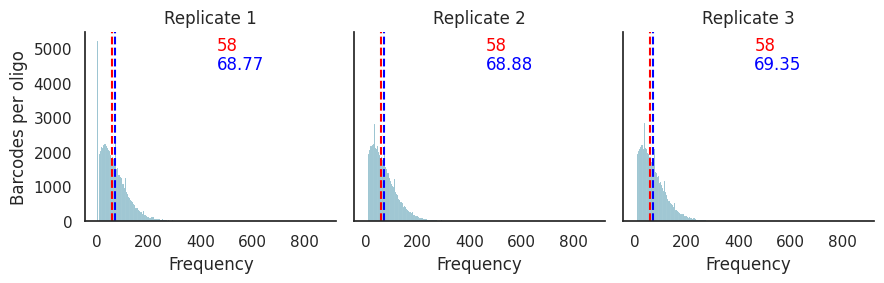

In [83]:
barcodes_per_oligo(NGN2_filtered_z_3.oligo_data)

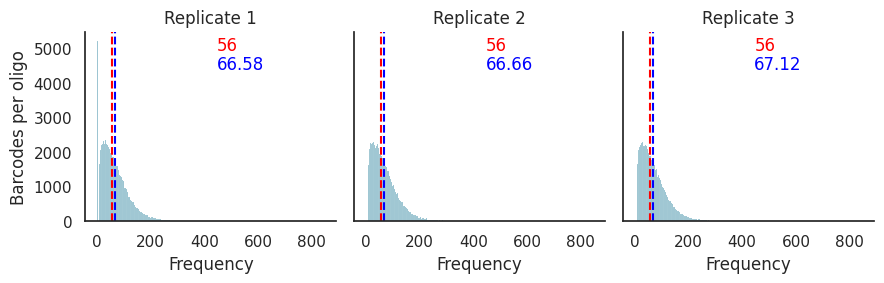

In [84]:
barcodes_per_oligo(NGN2_filtered_z_2.oligo_data)

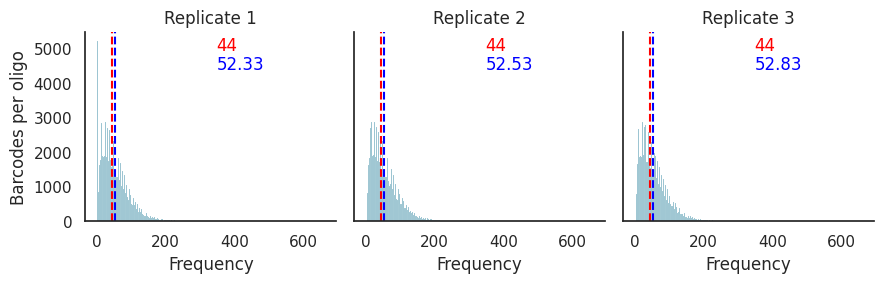

In [ ]:
barcodes_per_oligo(NGN2_filtered_z_1.oligo_data)

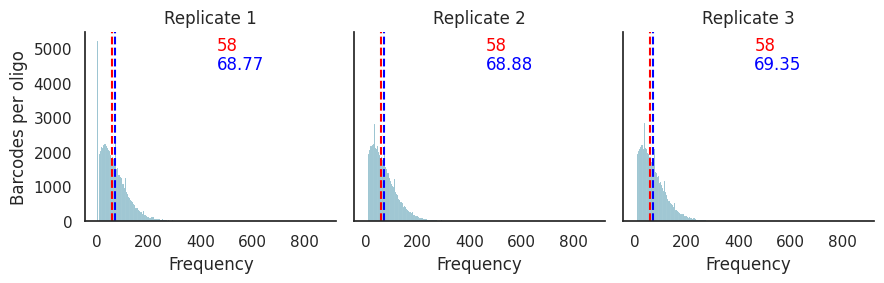

In [12]:
barcodes_per_oligo(NGN2_filtered_bc_10_z_3.oligo_data)

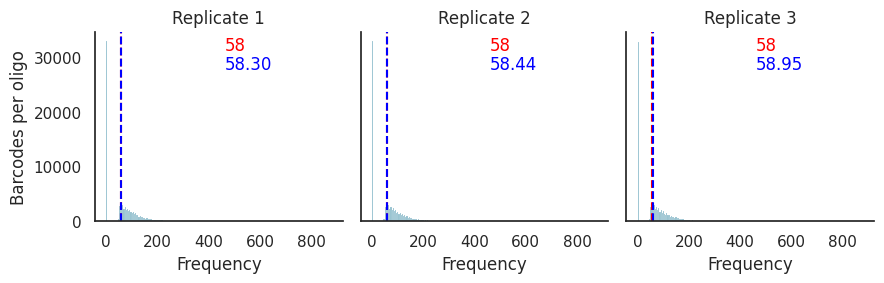

In [10]:
barcodes_per_oligo(NGN2_filtered_bc_50_z_3.oligo_data)

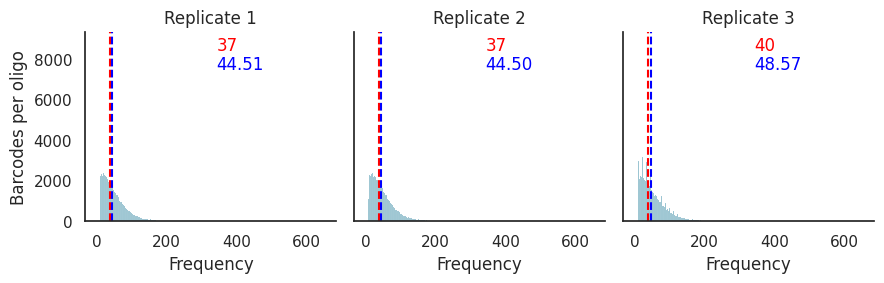

In [14]:
barcodes_per_oligo(WTC11_filtered_bc_10_z_3.oligo_data)

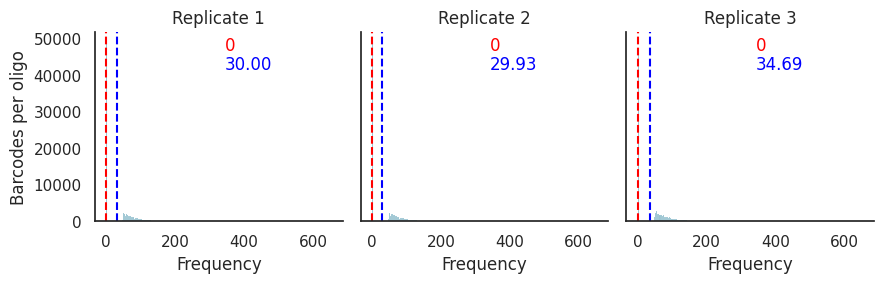

In [13]:
barcodes_per_oligo(WTC11_filtered_bc_50_z_3.oligo_data)

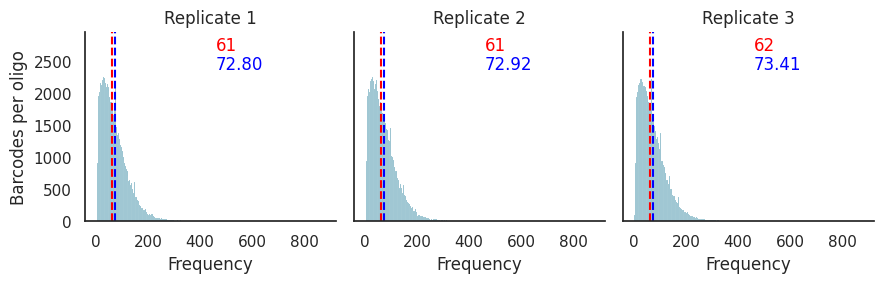

In [8]:
barcodes_per_oligo(NGN2_filtered_bc_10_z_3.oligo_data)

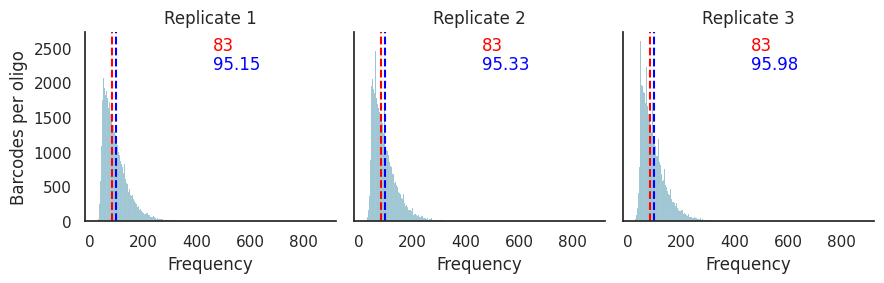

In [9]:
barcodes_per_oligo(NGN2_filtered_bc_50_z_3.oligo_data)

In [114]:
def dna_rna_norm(
        element_filtered: MPRABarcodeData
        )-> pd.DataFrame:
    dna_norm = pd.DataFrame(data = element_filtered.normalized_dna_counts,
                                index = element_filtered.data.obs_names,
                                columns = element_filtered.data.var_names
                                )
    dna_norm = dna_norm.T
    dna_norm.columns = ['DNA_norm_1', 'DNA_norm_2', 'DNA_norm_3']

    

    rna_norm = pd.DataFrame(data = element_filtered.normalized_rna_counts,
                                index = element_filtered.data.obs_names,
                                columns = element_filtered.data.var_names
                                )
    rna_norm = rna_norm.T
    rna_norm.columns = ['RNA_norm_1', 'RNA_norm_2', 'RNA_norm_3']


    return dna_norm.join(rna_norm)

In [115]:
def filter_and_normalize_barcodes(
    element_unfiltered: MPRABarcodeData,
    threshold: int = 10,
    z_score: int = 3
    ) -> pd.DataFrame:

    return dna_rna_norm(
        element_filtered = barcode_filter(
            element_unfiltered = element_unfiltered,
            z_score = z_score))

In [116]:
def map_oligo_to_barcode(filter_normalize_data: pd.DataFrame,
                         barcode_data: pd.DataFrame
                         )-> pd.DataFrame: 
    
    filter_normalize_data['oligo_name'] = filter_normalize_data.index.map(
        barcode_data.set_index('barcode')['oligo_name'].to_dict())
    
    filter_normalize_data.insert(
    loc = 0,
    column = 'oligo_name',
    value = filter_normalize_data.pop('oligo_name') 
    )
    return filter_normalize_data


In [117]:
def calculate_effect_size_per_replicate(
        filter_normalize_data: pd.DataFrame
        ) :
    num_replicates = filter_normalize_data.columns.str.contains('DNA_norm').sum()
    for i in range(1, num_replicates + 1): 
        filter_normalize_data[f'effect_size_{i}'] = np.log2(
            filter_normalize_data[f'RNA_norm_{i}'] 
            / filter_normalize_data[f'DNA_norm_{i}'])
    
    return filter_normalize_data



In [90]:
NGN2_z_3 = filter_and_normalize_barcodes(
    element_unfiltered = element_unfiltered_NGN2)
WTC11_z_3 = filter_and_normalize_barcodes(
    element_unfiltered = element_unfiltered_WTC11)
NGN2_z_2 = filter_and_normalize_barcodes(
    element_unfiltered = element_unfiltered_NGN2,
    z_score = 2)
WTC11_z_2 = filter_and_normalize_barcodes(
    element_unfiltered = element_unfiltered_WTC11,
    z_score = 2)
NGN2_z_1 = filter_and_normalize_barcodes(
    element_unfiltered = element_unfiltered_NGN2,
    z_score = 1)
WTC11_z_1 = filter_and_normalize_barcodes(
    element_unfiltered = element_unfiltered_WTC11,
    z_score = 1)

In [118]:
NGN2_filtered_bc_0_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                     threshold = 0)
WTC11_filtered_bc_0_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                      threshold = 0)
NGN2_filtered_bc_10_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                     threshold = 10)
WTC11_filtered_bc_10_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                      threshold = 10)
NGN2_filtered_bc_20_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                  threshold = 20)
WTC11_filtered_bc_20_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                    threshold = 20)
NGN2_filtered_bc_50_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                   threshold = 50)
WTC11_filtered_bc_50_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                    threshold = 50)

In [51]:
NGN2_filtered_bc_0_z_2 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                     threshold = 0,
                                     z_score = 2)
WTC11_filtered_bc_0_z_2 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                      threshold = 0,
                                      z_score = 2)
NGN2_filtered_bc_10_z_2 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                     threshold = 10,
                                     z_score = 2)
WTC11_filtered_bc_10_z_2 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                      threshold = 10,
                                      z_score = 2)
NGN2_filtered_bc_20_z_2 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                  threshold = 20,
                                  z_score = 2)
WTC11_filtered_bc_20_z_2 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                    threshold = 20,
                                    z_score = 2)
NGN2_filtered_bc_50_z_2 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                   threshold = 50,
                                   z_score = 2)
WTC11_filtered_bc_50_z_2 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                    threshold = 50,
                                    z_score = 2)

In [119]:
NGN2_filtered_bc_0_z_1 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                     threshold = 0,
                                     z_score = 1)
WTC11_filtered_bc_0_z_1 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                      threshold = 0,
                                      z_score = 1)
NGN2_filtered_bc_10_z_1 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                     threshold = 10,
                                     z_score = 1)
WTC11_filtered_bc_10_z_1 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                      threshold = 10,
                                      z_score = 1)
NGN2_filtered_bc_20_z_1 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                  threshold = 20,
                                  z_score = 1)
WTC11_filtered_bc_20_z_1 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                    threshold = 20,
                                    z_score = 1)
NGN2_filtered_bc_50_z_1 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                   threshold = 50,
                                   z_score = 1)
WTC11_filtered_bc_50_z_1 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                    threshold = 50,
                                    z_score = 1)

In [83]:
NGN2_filtered_bc_0_z_0 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                     threshold = 0,
                                     z_score = 0)
WTC11_filtered_bc_0_z_0 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                      threshold = 0,
                                      z_score = 0)
NGN2_filtered_bc_10_z_0 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                     threshold = 10,
                                     z_score = 0)
WTC11_filtered_bc_10_z_0 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                      threshold = 10,
                                      z_score = 0)
NGN2_filtered_bc_20_z_0 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                  threshold = 20,
                                  z_score = 0)
WTC11_filtered_bc_20_z_0 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                    threshold = 20,
                                    z_score = 0)
NGN2_filtered_bc_50_z_0 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2,
                                   threshold = 50,
                                   z_score = 0)
WTC11_filtered_bc_50_z_0 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11,
                                    threshold = 50,
                                    z_score = 0)

In [ ]:
NGN2_filtered_bc_10_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2_bc_10,
                                     threshold = 0)
WTC11_filtered_bc_10_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11_bc_10,
                                      threshold = 0)
NGN2_filtered_bc_20_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2_bc_20,
                                  threshold = 0)
WTC11_filtered_bc_20_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11_bc_20,
                                    threshold = 0)
NGN2_filtered_bc_50_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_NGN2_bc_50,
                                   threshold = 0)
WTC11_filtered_bc_50_z_3 = filter_and_normalize_barcodes(element_unfiltered = element_unfiltered_WTC11_bc_50,
                                    threshold = 0)

In [92]:
NGN2_map_z_3 = map_oligo_to_barcode(NGN2_z_3,
                                df_NGN2)
WTC11_map_z_3 = map_oligo_to_barcode(WTC11_z_3,
                                df_WTC11)
NGN2_map_z_2 = map_oligo_to_barcode(NGN2_z_2,
                                df_NGN2)
WTC11_map_z_2 = map_oligo_to_barcode(WTC11_z_2,
                                df_WTC11)
NGN2_map_z_1 = map_oligo_to_barcode(NGN2_z_1,
                                df_NGN2)
WTC11_map_z_1 = map_oligo_to_barcode(WTC11_z_1,
                                df_WTC11)

In [120]:
NGN2_map_bc_0_z_3 = map_oligo_to_barcode(NGN2_filtered_bc_0_z_3,
                                df_NGN2)
WTC11_map_bc_0_z_3 = map_oligo_to_barcode(WTC11_filtered_bc_0_z_3,
                                df_WTC11)
NGN2_map_bc_10_z_3 = map_oligo_to_barcode(NGN2_filtered_bc_10_z_3,
                                df_NGN2)
WTC11_map_bc_10_z_3 = map_oligo_to_barcode(WTC11_filtered_bc_10_z_3,
                                df_WTC11)
NGN2_map_bc_20_z_3 = map_oligo_to_barcode(NGN2_filtered_bc_20_z_3,
                                df_NGN2)
WTC11_map_bc_20_z_3 = map_oligo_to_barcode(WTC11_filtered_bc_20_z_3,
                                df_WTC11)
NGN2_map_bc_50_z_3 = map_oligo_to_barcode(NGN2_filtered_bc_50_z_3,
                                df_NGN2)
WTC11_map_bc_50_z_3 = map_oligo_to_barcode(WTC11_filtered_bc_50_z_3,
                                df_WTC11)

In [53]:
NGN2_map_bc_0_z_2 = map_oligo_to_barcode(NGN2_filtered_bc_0_z_2,
                                df_NGN2)
WTC11_map_bc_0_z_2 = map_oligo_to_barcode(WTC11_filtered_bc_0_z_2,
                                df_WTC11)
NGN2_map_bc_10_z_2 = map_oligo_to_barcode(NGN2_filtered_bc_10_z_2,
                                df_NGN2)
WTC11_map_bc_10_z_2 = map_oligo_to_barcode(WTC11_filtered_bc_10_z_2,
                                df_WTC11)
NGN2_map_bc_20_z_2 = map_oligo_to_barcode(NGN2_filtered_bc_20_z_2,
                                df_NGN2)
WTC11_map_bc_20_z_2 = map_oligo_to_barcode(WTC11_filtered_bc_20_z_2,
                                df_WTC11)
NGN2_map_bc_50_z_2 = map_oligo_to_barcode(NGN2_filtered_bc_50_z_2,
                                df_NGN2)
WTC11_map_bc_50_z_2 = map_oligo_to_barcode(WTC11_filtered_bc_50_z_2,
                                df_WTC11)

In [121]:
NGN2_map_bc_0_z_1 = map_oligo_to_barcode(NGN2_filtered_bc_0_z_1,
                                df_NGN2)
WTC11_map_bc_0_z_1 = map_oligo_to_barcode(WTC11_filtered_bc_0_z_1,
                                df_WTC11)
NGN2_map_bc_10_z_1 = map_oligo_to_barcode(NGN2_filtered_bc_10_z_1,
                                df_NGN2)
WTC11_map_bc_10_z_1 = map_oligo_to_barcode(WTC11_filtered_bc_10_z_1,
                                df_WTC11)
NGN2_map_bc_20_z_1 = map_oligo_to_barcode(NGN2_filtered_bc_20_z_1,
                                df_NGN2)
WTC11_map_bc_20_z_1 = map_oligo_to_barcode(WTC11_filtered_bc_20_z_1,
                                df_WTC11)
NGN2_map_bc_50_z_1 = map_oligo_to_barcode(NGN2_filtered_bc_50_z_1,
                                df_NGN2)
WTC11_map_bc_50_z_1 = map_oligo_to_barcode(WTC11_filtered_bc_50_z_1,
                                df_WTC11)

In [84]:
NGN2_map_bc_0_z_0 = map_oligo_to_barcode(NGN2_filtered_bc_0_z_0,
                                df_NGN2)
WTC11_map_bc_0_z_0 = map_oligo_to_barcode(WTC11_filtered_bc_0_z_0,
                                df_WTC11)
NGN2_map_bc_10_z_0 = map_oligo_to_barcode(NGN2_filtered_bc_10_z_0,
                                df_NGN2)
WTC11_map_bc_10_z_0 = map_oligo_to_barcode(WTC11_filtered_bc_10_z_0,
                                df_WTC11)
NGN2_map_bc_20_z_0 = map_oligo_to_barcode(NGN2_filtered_bc_20_z_0,
                                df_NGN2)
WTC11_map_bc_20_z_0 = map_oligo_to_barcode(WTC11_filtered_bc_20_z_0,
                                df_WTC11)
NGN2_map_bc_50_z_0 = map_oligo_to_barcode(NGN2_filtered_bc_50_z_0,
                                df_NGN2)
WTC11_map_bc_50_z_0 = map_oligo_to_barcode(WTC11_filtered_bc_50_z_0,
                                df_WTC11)

In [122]:
NGN2_map_bc_0_z_3 = threshold_filter(
    data_table = NGN2_map_bc_0_z_3.reset_index(),
    threshold = 0)
WTC11_map_bc_0_z_3 = threshold_filter(
    data_table = WTC11_map_bc_0_z_3.reset_index(),
    threshold = 0)
NGN2_map_bc_10_z_3 = threshold_filter(
    data_table = NGN2_map_bc_10_z_3.reset_index(),
    threshold = 10)
WTC11_map_bc_10_z_3 = threshold_filter(
    data_table = WTC11_map_bc_10_z_3.reset_index(),
    threshold = 10)
NGN2_map_bc_20_z_3 = threshold_filter(
    data_table = NGN2_map_bc_20_z_3.reset_index(),
    threshold = 20)
WTC11_map_bc_20_z_3 = threshold_filter(
    data_table = WTC11_map_bc_20_z_3.reset_index(),
    threshold = 20)
NGN2_map_bc_50_z_3 = threshold_filter(
    data_table = NGN2_map_bc_50_z_3.reset_index(),
    threshold = 50)
WTC11_map_bc_50_z_3 = threshold_filter(
    data_table = WTC11_map_bc_50_z_3.reset_index(),
    threshold = 50)

In [55]:
NGN2_map_bc_0_z_2 = threshold_filter(
    data_table = NGN2_map_bc_0_z_2.reset_index(),
    threshold = 0)
WTC11_map_bc_0_z_2 = threshold_filter(
    data_table = WTC11_map_bc_0_z_2.reset_index(),
    threshold = 0)
NGN2_map_bc_20_z_2 = threshold_filter(
    data_table = NGN2_map_bc_20_z_2.reset_index(),
    threshold = 20)
WTC11_map_bc_20_z_2 = threshold_filter(
    data_table = WTC11_map_bc_20_z_2.reset_index(),
    threshold = 20)
NGN2_map_bc_50_z_2 = threshold_filter(
    data_table = NGN2_map_bc_50_z_2.reset_index(),
    threshold = 50)
WTC11_map_bc_50_z_2 = threshold_filter(
    data_table = WTC11_map_bc_50_z_2.reset_index(),
    threshold = 50)

In [123]:
NGN2_map_bc_0_z_1 = threshold_filter(
    data_table = NGN2_map_bc_0_z_1.reset_index(),
    threshold = 0)
WTC11_map_bc_0_z_1 = threshold_filter(
    data_table = WTC11_map_bc_0_z_1.reset_index(),
    threshold = 0)
NGN2_map_bc_10_z_1 = threshold_filter(
    data_table = NGN2_map_bc_10_z_1.reset_index(),
    threshold = 10)
WTC11_map_bc_10_z_1 = threshold_filter(
    data_table = WTC11_map_bc_10_z_1.reset_index(),
    threshold = 10)
NGN2_map_bc_20_z_1 = threshold_filter(
    data_table = NGN2_map_bc_20_z_1.reset_index(),
    threshold = 20)
WTC11_map_bc_20_z_1 = threshold_filter(
    data_table = WTC11_map_bc_20_z_1.reset_index(),
    threshold = 20)
NGN2_map_bc_50_z_1 = threshold_filter(
    data_table = NGN2_map_bc_50_z_1.reset_index(),
    threshold = 50)
WTC11_map_bc_50_z_1 = threshold_filter(
    data_table = WTC11_map_bc_50_z_1.reset_index(),
    threshold = 50)

In [85]:
NGN2_map_bc_0_z_0 = threshold_filter(
    data_table = NGN2_map_bc_0_z_0.reset_index(),
    threshold = 0)
WTC11_map_bc_0_z_0 = threshold_filter(
    data_table = WTC11_map_bc_0_z_0.reset_index(),
    threshold = 0)
NGN2_map_bc_10_z_0 = threshold_filter(
    data_table = NGN2_map_bc_10_z_0.reset_index(),
    threshold = 10)
WTC11_map_bc_10_z_0 = threshold_filter(
    data_table = WTC11_map_bc_10_z_0.reset_index(),
    threshold = 10)
NGN2_map_bc_20_z_0 = threshold_filter(
    data_table = NGN2_map_bc_20_z_0.reset_index(),
    threshold = 20)
WTC11_map_bc_20_z_0 = threshold_filter(
    data_table = WTC11_map_bc_20_z_0.reset_index(),
    threshold = 20)
NGN2_map_bc_50_z_0 = threshold_filter(
    data_table = NGN2_map_bc_50_z_0.reset_index(),
    threshold = 50)
WTC11_map_bc_50_z_0 = threshold_filter(
    data_table = WTC11_map_bc_50_z_0.reset_index(),
    threshold = 50)

In [94]:
NGN2_calculate_effect_size_z_3 = calculate_effect_size_per_replicate(NGN2_map_z_3)
WTC11_calculate_effect_size_z_3 = calculate_effect_size_per_replicate(WTC11_map_z_3)
NGN2_calculate_effect_size_z_2 = calculate_effect_size_per_replicate(NGN2_map_z_2)
WTC11_calculate_effect_size_z_2 = calculate_effect_size_per_replicate(WTC11_map_z_2)
NGN2_calculate_effect_size_z_1 = calculate_effect_size_per_replicate(NGN2_map_z_1)
WTC11_calculate_effect_size_z_1 = calculate_effect_size_per_replicate(WTC11_map_z_1)



In [124]:
NGN2_calculate_effect_size_bc_0_z_3 = calculate_effect_size_per_replicate(NGN2_map_bc_0_z_3)
WTC11_calculate_effect_size_bc_0_z_3 = calculate_effect_size_per_replicate(WTC11_map_bc_0_z_3)
NGN2_calculate_effect_size_bc_10_z_3 = calculate_effect_size_per_replicate(NGN2_map_bc_10_z_3)
WTC11_calculate_effect_size_bc_10_z_3 = calculate_effect_size_per_replicate(WTC11_map_bc_10_z_3)
NGN2_calculate_effect_size_bc_20_z_3 = calculate_effect_size_per_replicate(NGN2_map_bc_20_z_3)
WTC11_calculate_effect_size_bc_20_z_3 = calculate_effect_size_per_replicate(WTC11_map_bc_20_z_3)
NGN2_calculate_effect_size_bc_50_z_3 = calculate_effect_size_per_replicate(NGN2_map_bc_50_z_3)
WTC11_calculate_effect_size_bc_50_z_3 = calculate_effect_size_per_replicate(WTC11_map_bc_50_z_3)

In [62]:
NGN2_calculate_effect_size_bc_0_z_2 = calculate_effect_size_per_replicate(NGN2_map_bc_0_z_2)
WTC11_calculate_effect_size_bc_0_z_2 = calculate_effect_size_per_replicate(WTC11_map_bc_0_z_2)
NGN2_calculate_effect_size_bc_10_z_3 = calculate_effect_size_per_replicate(NGN2_map_bc_10_z_3)
WTC11_calculate_effect_size_bc_10_z_3 = calculate_effect_size_per_replicate(WTC11_map_bc_10_z_3)
NGN2_calculate_effect_size_bc_20_z_2 = calculate_effect_size_per_replicate(NGN2_map_bc_20_z_2)
WTC11_calculate_effect_size_bc_20_z_2 = calculate_effect_size_per_replicate(WTC11_map_bc_20_z_2)
NGN2_calculate_effect_size_bc_50_z_2 = calculate_effect_size_per_replicate(NGN2_map_bc_50_z_2)
WTC11_calculate_effect_size_bc_50_z_2 = calculate_effect_size_per_replicate(WTC11_map_bc_50_z_2)

In [125]:
NGN2_calculate_effect_size_bc_0_z_1 = calculate_effect_size_per_replicate(NGN2_map_bc_0_z_1)
WTC11_calculate_effect_size_bc_0_z_1 = calculate_effect_size_per_replicate(WTC11_map_bc_0_z_1)
NGN2_calculate_effect_size_bc_10_z_1 = calculate_effect_size_per_replicate(NGN2_map_bc_10_z_1)
WTC11_calculate_effect_size_bc_10_z_1 = calculate_effect_size_per_replicate(WTC11_map_bc_10_z_1)
NGN2_calculate_effect_size_bc_20_z_1 = calculate_effect_size_per_replicate(NGN2_map_bc_20_z_1)
WTC11_calculate_effect_size_bc_20_z_1 = calculate_effect_size_per_replicate(WTC11_map_bc_20_z_1)
NGN2_calculate_effect_size_bc_50_z_1 = calculate_effect_size_per_replicate(NGN2_map_bc_50_z_1)
WTC11_calculate_effect_size_bc_50_z_1 = calculate_effect_size_per_replicate(WTC11_map_bc_50_z_1)

In [86]:
NGN2_calculate_effect_size_bc_0_z_0 = calculate_effect_size_per_replicate(NGN2_map_bc_0_z_0)
WTC11_calculate_effect_size_bc_0_z_0 = calculate_effect_size_per_replicate(WTC11_map_bc_0_z_0)
NGN2_calculate_effect_size_bc_10_z_0 = calculate_effect_size_per_replicate(NGN2_map_bc_10_z_0)
WTC11_calculate_effect_size_bc_10_z_0 = calculate_effect_size_per_replicate(WTC11_map_bc_10_z_0)
NGN2_calculate_effect_size_bc_20_z_0 = calculate_effect_size_per_replicate(NGN2_map_bc_20_z_0)
WTC11_calculate_effect_size_bc_20_z_0 = calculate_effect_size_per_replicate(WTC11_map_bc_20_z_0)
NGN2_calculate_effect_size_bc_50_z_0 = calculate_effect_size_per_replicate(NGN2_map_bc_50_z_0)
WTC11_calculate_effect_size_bc_50_z_0 = calculate_effect_size_per_replicate(WTC11_map_bc_50_z_0)

In [133]:
len(NGN2_calculate_effect_size_bc_0_z_1), len(NGN2_calculate_effect_size_bc_0_z_3)

(6386341, 6386341)

In [136]:
len(WTC11_calculate_effect_size_bc_20_z_1), len(WTC11_calculate_effect_size_bc_20_z_3)

(5412706, 5412706)

In [29]:
def count_barcodes_per_oligo(
        oligo_per_barcode_tabel: pd.DataFrame
        ) -> pd.DataFrame:

    return oligo_per_barcode_tabel.groupby(
        by = 'oligo_name').size().reset_index(
            name = 'n_barcodes'
        )

In [97]:
NGN2_barcodes_per_oligo_z_3 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_z_3
)
WTC11_barcodes_per_oligo_z_3 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_z_3
)
NGN2_barcodes_per_oligo_z_2 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_z_2
)
WTC11_barcodes_per_oligo_z_2 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_z_2
)
NGN2_barcodes_per_oligo_z_1 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_z_1
)
WTC11_barcodes_per_oligo_z_1 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_z_1
)

In [30]:
NGN2_barcodes_per_oligo_bc_0_z_3 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_0_z_3
)
WTC11_barcodes_per_oligo_bc_0_z_3 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_0_z_3
)
NGN2_barcodes_per_oligo_bc_10_z_3 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_10_z_3
)
WTC11_barcodes_per_oligo_bc_10_z_3 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_10_z_3
)
NGN2_barcodes_per_oligo_bc_20_z_3 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_20_z_3
)
WTC11_barcodes_per_oligo_bc_20_z_3 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_20_z_3
)
NGN2_barcodes_per_oligo_bc_50_z_3 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_50_z_3
)
WTC11_barcodes_per_oligo_bc_50_z_3 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_50_z_3
)

In [63]:
NGN2_barcodes_per_oligo_bc_0_z_2 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_0_z_2
)
WTC11_barcodes_per_oligo_bc_0_z_2 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_0_z_2
)
NGN2_barcodes_per_oligo_bc_10_z_2 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_10_z_2
)
WTC11_barcodes_per_oligo_bc_10_z_2 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_10_z_2
)
NGN2_barcodes_per_oligo_bc_20_z_2 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_20_z_2
)
WTC11_barcodes_per_oligo_bc_20_z_2 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_20_z_2
)
NGN2_barcodes_per_oligo_bc_50_z_2 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_50_z_2
)
WTC11_barcodes_per_oligo_bc_50_z_2 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_50_z_2
)

In [18]:
NGN2_barcodes_per_oligo_bc_0_z_1 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_0_z_1
)
WTC11_barcodes_per_oligo_bc_0_z_1 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_0_z_1
)
NGN2_barcodes_per_oligo_bc_10_z_1 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_10_z_1
)
WTC11_barcodes_per_oligo_bc_10_z_1 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_10_z_1
)
NGN2_barcodes_per_oligo_bc_20_z_1 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_20_z_1
)
WTC11_barcodes_per_oligo_bc_20_z_1 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_20_z_1
)
NGN2_barcodes_per_oligo_bc_50_z_1 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_50_z_1
)
WTC11_barcodes_per_oligo_bc_50_z_1 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_50_z_1
)

In [87]:
NGN2_barcodes_per_oligo_bc_0_z_0 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_0_z_0
)
WTC11_barcodes_per_oligo_bc_0_z_0 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_0_z_0
)
NGN2_barcodes_per_oligo_bc_10_z_0 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_10_z_0
)
WTC11_barcodes_per_oligo_bc_10_z_0 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_10_z_0
)
NGN2_barcodes_per_oligo_bc_20_z_0 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_20_z_0
)
WTC11_barcodes_per_oligo_bc_20_z_0 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_20_z_0
)
NGN2_barcodes_per_oligo_bc_50_z_0 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = NGN2_calculate_effect_size_bc_50_z_0
)
WTC11_barcodes_per_oligo_bc_50_z_0 = count_barcodes_per_oligo(
    oligo_per_barcode_tabel = WTC11_calculate_effect_size_bc_50_z_0
)

In [23]:
(WTC11_barcodes_per_oligo_bc_50_z_3['n_barcodes'] < 51).sum()

np.int64(700)

In [88]:
def plot_barcode_per_oligo(
        barcode_per_oligo_tabels: list,
        cell_names: list
        ):
    
    fig, axes = plt.subplots(1,
                             len(barcode_per_oligo_tabels), 
                                figsize = (5 * len(barcode_per_oligo_tabels), 5))
    for table, ax, cell_name in zip(barcode_per_oligo_tabels, axes, cell_names):
        sns.violinplot(
            data=table,
            y='n_barcodes',
            ax=ax
        )
        ax.set_ylabel('Barcodes per oligo')
        ax.set_title(cell_name)

    

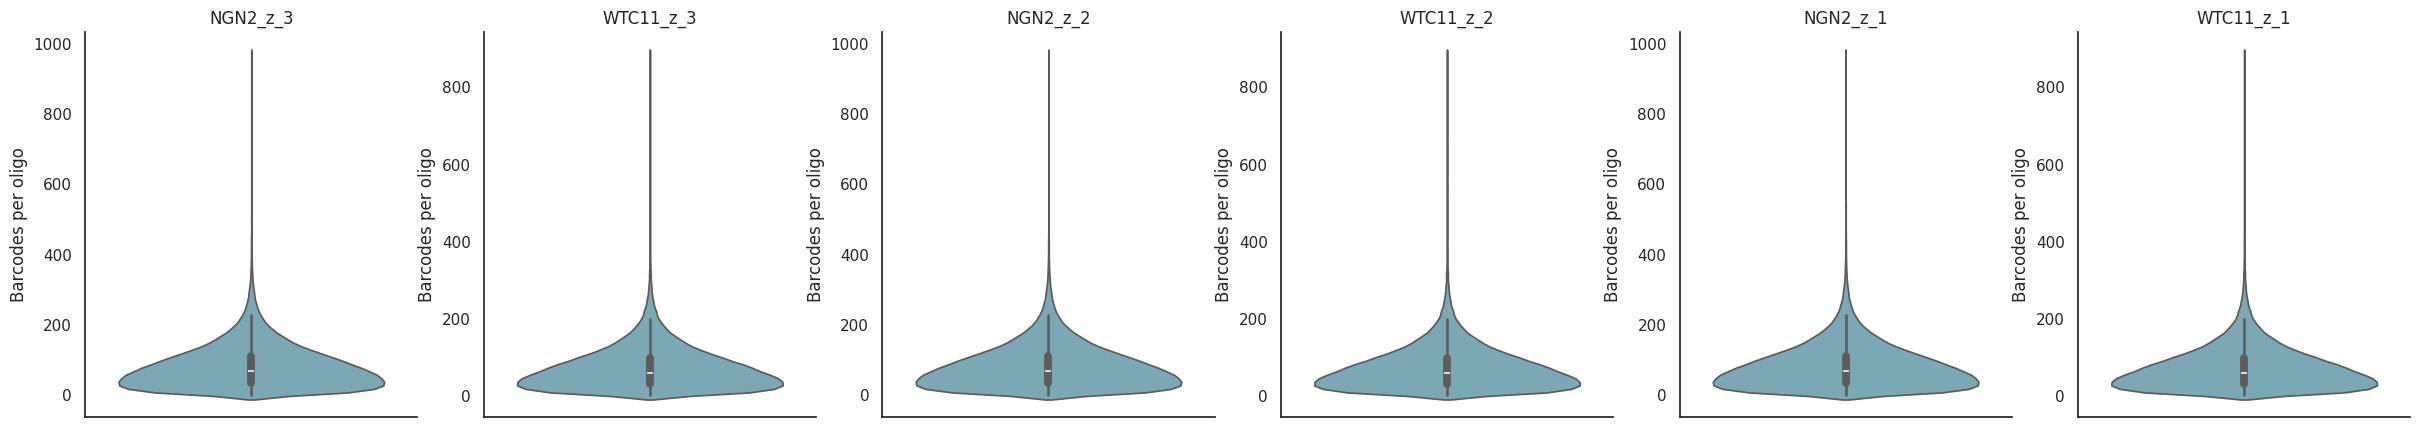

In [ ]:
plot_barcode_per_oligo([NGN2_barcodes_per_oligo_z_3, 
                        WTC11_barcodes_per_oligo_z_3, 
                        NGN2_barcodes_per_oligo_z_2, 
                        WTC11_barcodes_per_oligo_z_2,
                        NGN2_barcodes_per_oligo_z_1,
                        WTC11_barcodes_per_oligo_z_1],
                       ['NGN2_z_3', 'WTC11_z_3', 'NGN2_z_2', 'WTC11_z_2', 'NGN2_z_1', 'WTC11_z_1'])

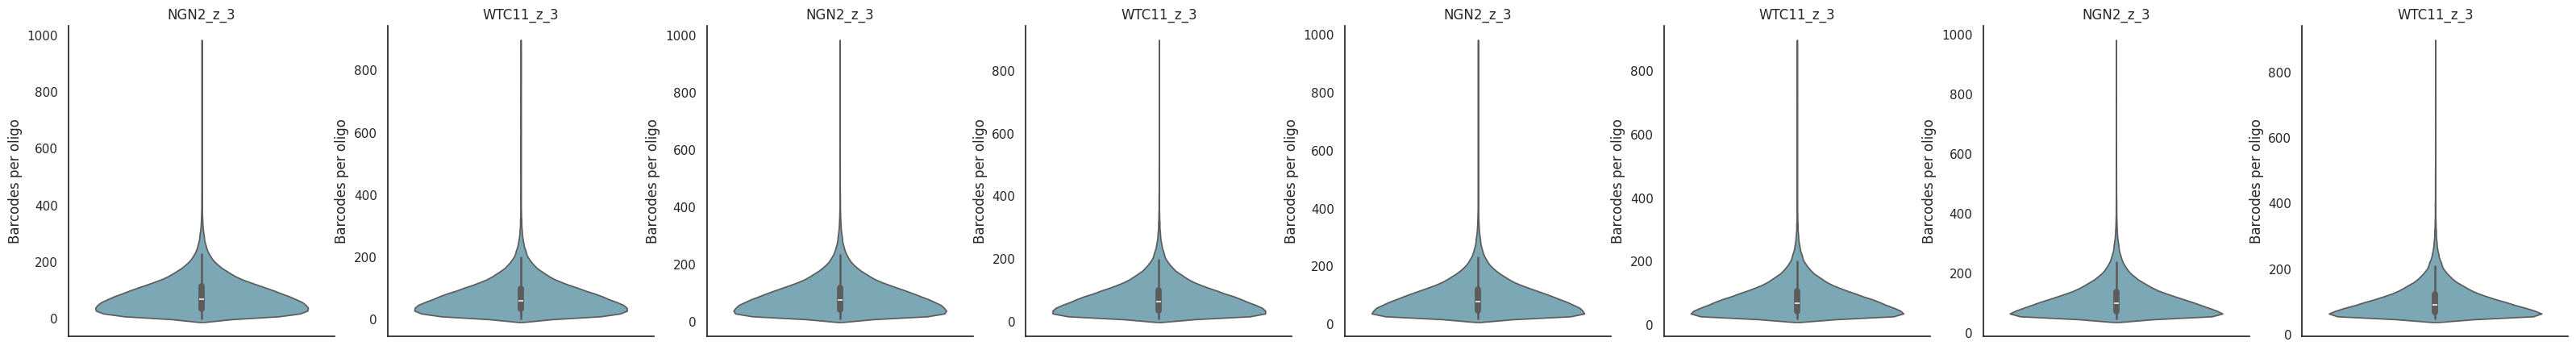

In [65]:
plot_barcode_per_oligo([NGN2_barcodes_per_oligo_bc_0_z_3, 
                        WTC11_barcodes_per_oligo_bc_0_z_3,
                        NGN2_barcodes_per_oligo_bc_10_z_3, 
                        WTC11_barcodes_per_oligo_bc_10_z_3, 
                        NGN2_barcodes_per_oligo_bc_20_z_3, 
                        WTC11_barcodes_per_oligo_bc_20_z_3,
                        NGN2_barcodes_per_oligo_bc_50_z_3,
                        WTC11_barcodes_per_oligo_bc_50_z_3],
                       ['NGN2_z_3', 'WTC11_z_3', 'NGN2_z_3', 'WTC11_z_3', 'NGN2_z_3', 'WTC11_z_3', 'NGN2_z_3', 'WTC11_z_3'])

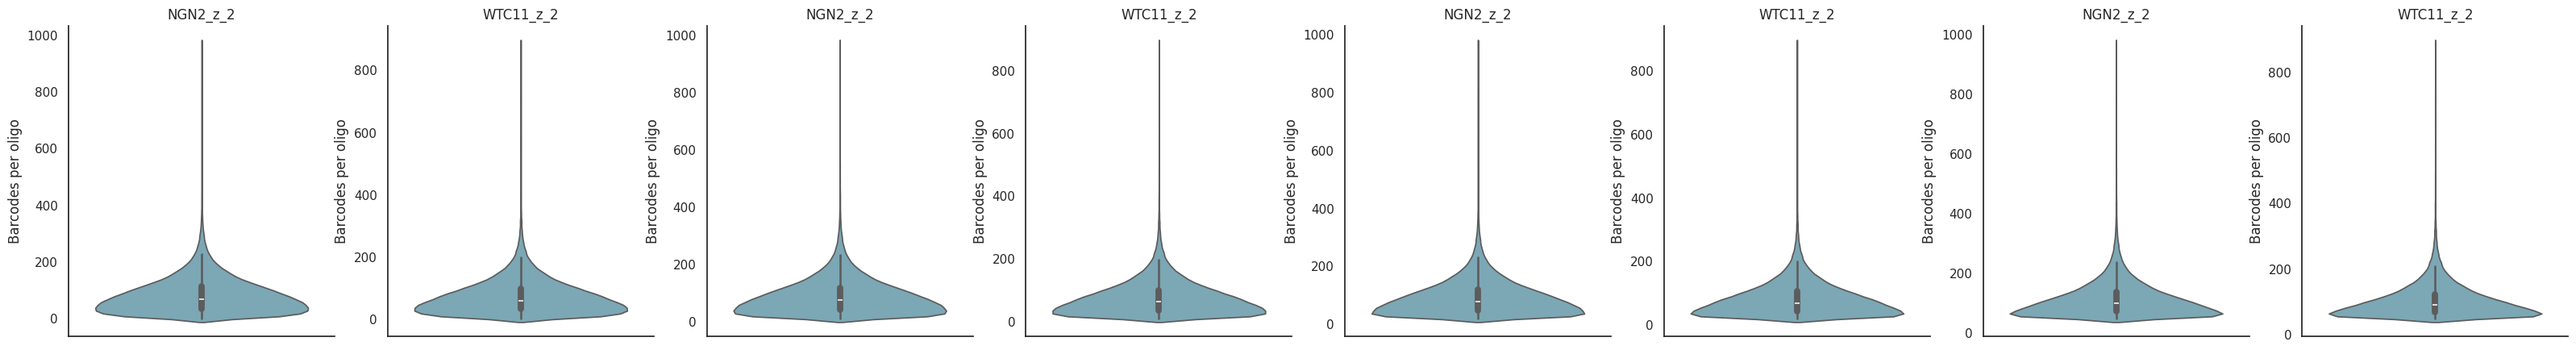

In [67]:
plot_barcode_per_oligo([NGN2_barcodes_per_oligo_bc_0_z_2, 
                        WTC11_barcodes_per_oligo_bc_0_z_2,
                        NGN2_barcodes_per_oligo_bc_10_z_2, 
                        WTC11_barcodes_per_oligo_bc_10_z_2, 
                        NGN2_barcodes_per_oligo_bc_20_z_2, 
                        WTC11_barcodes_per_oligo_bc_20_z_2,
                        NGN2_barcodes_per_oligo_bc_50_z_2,
                        WTC11_barcodes_per_oligo_bc_50_z_2],
                       ['NGN2_z_2', 'WTC11_z_2', 'NGN2_z_2', 'WTC11_z_2', 'NGN2_z_2', 'WTC11_z_2', 'NGN2_z_2', 'WTC11_z_2'])

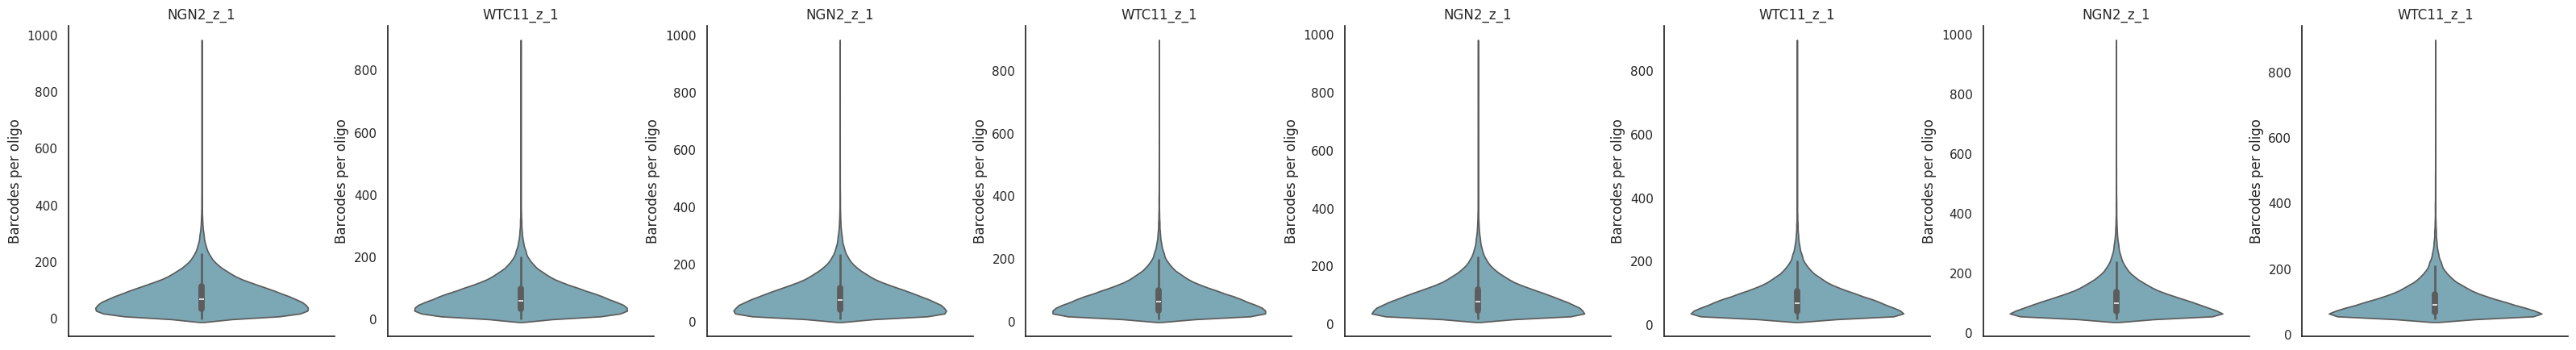

In [20]:
plot_barcode_per_oligo([NGN2_barcodes_per_oligo_bc_0_z_1, 
                        WTC11_barcodes_per_oligo_bc_0_z_1,
                        NGN2_barcodes_per_oligo_bc_10_z_1, 
                        WTC11_barcodes_per_oligo_bc_10_z_1, 
                        NGN2_barcodes_per_oligo_bc_20_z_1, 
                        WTC11_barcodes_per_oligo_bc_20_z_1,
                        NGN2_barcodes_per_oligo_bc_50_z_1,
                        WTC11_barcodes_per_oligo_bc_50_z_1],
                       ['NGN2_z_1', 'WTC11_z_1', 'NGN2_z_1', 'WTC11_z_1', 'NGN2_z_1', 'WTC11_z_1', 'NGN2_z_1', 'WTC11_z_1'])

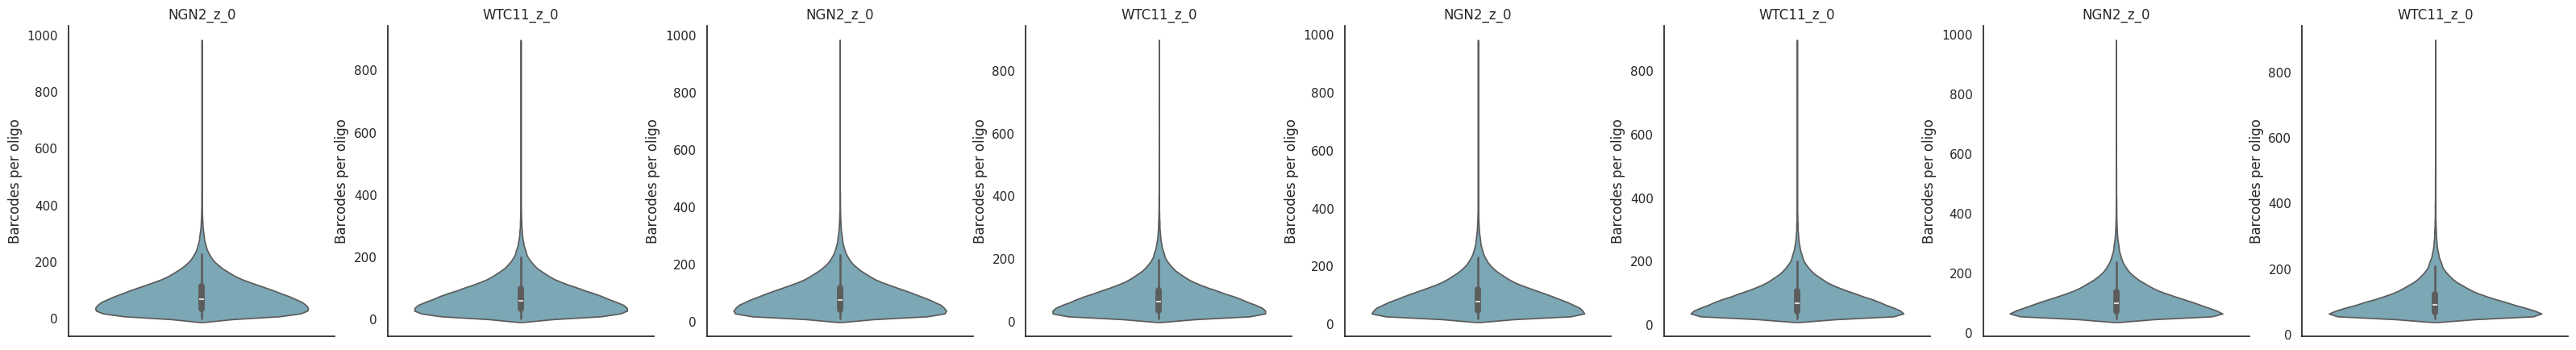

In [89]:
plot_barcode_per_oligo([NGN2_barcodes_per_oligo_bc_0_z_0, 
                        WTC11_barcodes_per_oligo_bc_0_z_0,
                        NGN2_barcodes_per_oligo_bc_10_z_0, 
                        WTC11_barcodes_per_oligo_bc_10_z_0, 
                        NGN2_barcodes_per_oligo_bc_20_z_0, 
                        WTC11_barcodes_per_oligo_bc_20_z_0,
                        NGN2_barcodes_per_oligo_bc_50_z_0,
                        WTC11_barcodes_per_oligo_bc_50_z_0],
                       ['NGN2_z_0', 'WTC11_z_0', 'NGN2_z_0', 'WTC11_z_0', 'NGN2_z_0', 'WTC11_z_0', 'NGN2_z_0', 'WTC11_z_0'])

In [32]:
def reshape_replicate_effect_sizes(
        barcode_oligo_effect_sizes: pd.DataFrame
        )-> pd.DataFrame:

    num_rep = barcode_oligo_effect_sizes.columns.str.contains('effect_size_').sum()
    num_rep_array = [f'effect_size_{i}' for i in range(1,num_rep+1)]

    return barcode_oligo_effect_sizes.melt(
        id_vars = 'oligo_name',
        value_vars = num_rep_array,
        value_name = 'effect_size'
    )

In [103]:
NGN2_reshape_effect_size_z_3 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_z_3)
WTC11_reshape_effect_size_z_3 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_z_3)
NGN2_reshape_effect_size_z_2 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_z_2)
WTC11_reshape_effect_size_z_2 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_z_2)
NGN2_reshape_effect_size_z_1 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_z_1)
WTC11_reshape_effect_size_z_1 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_z_1)



In [33]:
NGN2_reshape_effect_size_bc_0_z_3 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_0_z_3)
WTC11_reshape_effect_size_bc_0_z_3 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_0_z_3)
NGN2_reshape_effect_size_bc_10_z_3 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_10_z_3)
WTC11_reshape_effect_size_bc_10_z_3 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_10_z_3)
NGN2_reshape_effect_size_bc_20_z_3 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_20_z_3)
WTC11_reshape_effect_size_bc_20_z_3 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_20_z_3)
NGN2_reshape_effect_size_bc_50_z_3 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_50_z_3)
WTC11_reshape_effect_size_bc_50_z_3 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_50_z_3)



In [69]:
NGN2_reshape_effect_size_bc_0_z_2 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_0_z_2)
WTC11_reshape_effect_size_bc_0_z_2 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_0_z_2)
NGN2_reshape_effect_size_bc_10_z_2 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_10_z_2)
WTC11_reshape_effect_size_bc_10_z_2 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_10_z_2)
NGN2_reshape_effect_size_bc_20_z_2 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_20_z_2)
WTC11_reshape_effect_size_bc_20_z_2 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_20_z_2)
NGN2_reshape_effect_size_bc_50_z_2 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_50_z_2)
WTC11_reshape_effect_size_bc_50_z_2 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_50_z_2)



In [22]:
NGN2_reshape_effect_size_bc_0_z_1 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_0_z_1)
WTC11_reshape_effect_size_bc_0_z_1 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_0_z_1)
NGN2_reshape_effect_size_bc_10_z_1 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_10_z_1)
WTC11_reshape_effect_size_bc_10_z_1 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_10_z_1)
NGN2_reshape_effect_size_bc_20_z_1 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_20_z_1)
WTC11_reshape_effect_size_bc_20_z_1 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_20_z_1)
NGN2_reshape_effect_size_bc_50_z_1 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_50_z_1)
WTC11_reshape_effect_size_bc_50_z_1 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_50_z_1)



In [90]:
NGN2_reshape_effect_size_bc_0_z_0 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_0_z_0)
WTC11_reshape_effect_size_bc_0_z_0 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_0_z_0)
NGN2_reshape_effect_size_bc_10_z_0 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_10_z_0)
WTC11_reshape_effect_size_bc_10_z_0 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_10_z_0)
NGN2_reshape_effect_size_bc_20_z_0 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_20_z_0)
WTC11_reshape_effect_size_bc_20_z_0 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_20_z_0)
NGN2_reshape_effect_size_bc_50_z_0 = reshape_replicate_effect_sizes(NGN2_calculate_effect_size_bc_50_z_0)
WTC11_reshape_effect_size_bc_50_z_0 = reshape_replicate_effect_sizes(WTC11_calculate_effect_size_bc_50_z_0)



In [34]:
def aggregate_effect_size_mean_var_per_oligo(reshape_replicate_data: pd.DataFrame
                                             ):
    
    return (
        reshape_replicate_data.groupby('oligo_name')['effect_size'].agg(
            ['mean', 'var'])
        ).reset_index()

In [35]:
def rename_aggregate_columns(
        aggregate_tabel: pd.DataFrame,
        cell_type: str
    ):

    return aggregate_tabel.rename(columns = {
        'mean': f'mean_{cell_type}',
        'var': f'var_{cell_type}'
    })

In [106]:
NGN2_oligo_effect_size_stats_z_3 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_z_3),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_z_3 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_z_3),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_z_2 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_z_2),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_z_2 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_z_2),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_z_1 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_z_1),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_z_1 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_z_1),
    cell_type = 'WTC11')

In [36]:
NGN2_oligo_effect_size_stats_bc_0_z_3 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_0_z_3),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_0_z_3 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_0_z_3),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_10_z_3 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_10_z_3),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_10_z_3 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_10_z_3),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_20_z_3 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_20_z_3),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_20_z_3 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_20_z_3),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_50_z_3 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_50_z_3),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_50_z_3 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_50_z_3),
    cell_type = 'WTC11')

In [71]:
NGN2_oligo_effect_size_stats_bc_0_z_2 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_0_z_2),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_0_z_2 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_0_z_2),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_10_z_2 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_10_z_2),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_10_z_2 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_10_z_2),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_20_z_2 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_20_z_2),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_20_z_2 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_20_z_2),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_50_z_2 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_50_z_2),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_50_z_2 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_50_z_2),
    cell_type = 'WTC11')

In [25]:
NGN2_oligo_effect_size_stats_bc_0_z_1 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_0_z_1),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_0_z_1 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_0_z_1),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_10_z_1 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_10_z_1),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_10_z_1 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_10_z_1),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_20_z_1 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_20_z_1),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_20_z_1 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_20_z_1),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_50_z_1 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_50_z_1),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_50_z_1 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_50_z_1),
    cell_type = 'WTC11')

In [91]:
NGN2_oligo_effect_size_stats_bc_0_z_0 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_0_z_0),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_0_z_0 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_0_z_0),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_10_z_0 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_10_z_0),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_10_z_0 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_10_z_0),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_20_z_0 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_20_z_0),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_20_z_0 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_20_z_0),
    cell_type = 'WTC11')
NGN2_oligo_effect_size_stats_bc_50_z_0 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(NGN2_reshape_effect_size_bc_50_z_0),
    cell_type = 'NGN2')
WTC11_oligo_effect_size_stats_bc_50_z_0 = rename_aggregate_columns(
    aggregate_tabel = aggregate_effect_size_mean_var_per_oligo(WTC11_reshape_effect_size_bc_50_z_0),
    cell_type = 'WTC11')

In [37]:
def merge_aggregate_tables(
        aggregate_tables: list[pd.DataFrame],
        on = 'oligo_name'
        ) -> pd.DataFrame:
    merged = aggregate_tables[0].copy()

    for table in aggregate_tables[1:]:
        merged = merged.merge(
            table,
            how ='outer',
            on = on
        )

    return merged

In [108]:
NGN2_WTC11_var_mean_merge_z_3 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_z_3, 
                                                    WTC11_oligo_effect_size_stats_z_3])
NGN2_WTC11_var_mean_merge_z_2 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_z_2, 
                                                    WTC11_oligo_effect_size_stats_z_2])
NGN2_WTC11_var_mean_merge_z_1 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_z_1, 
                                                    WTC11_oligo_effect_size_stats_z_1])


In [38]:
NGN2_WTC11_var_mean_merge_bc_0_z_3 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_0_z_3, 
                                                    WTC11_oligo_effect_size_stats_bc_0_z_3])
NGN2_WTC11_var_mean_merge_bc_10_z_3 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_10_z_3, 
                                                    WTC11_oligo_effect_size_stats_bc_10_z_3])
NGN2_WTC11_var_mean_merge_bc_20_z_3 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_20_z_3, 
                                                    WTC11_oligo_effect_size_stats_bc_20_z_3])
NGN2_WTC11_var_mean_merge_bc_50_z_3 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_50_z_3, 
                                                    WTC11_oligo_effect_size_stats_bc_50_z_3])


In [ ]:
NGN2_WTC11_var_mean_merge_bc_0_z_2 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_0_z_2, 
                                                    WTC11_oligo_effect_size_stats_bc_0_z_2])
NGN2_WTC11_var_mean_merge_bc_10_z_2 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_10_z_2, 
                                                    WTC11_oligo_effect_size_stats_bc_10_z_2])
NGN2_WTC11_var_mean_merge_bc_20_z_2 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_20_z_2, 
                                                    WTC11_oligo_effect_size_stats_bc_20_z_2])
NGN2_WTC11_var_mean_merge_bc_50_z_2 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_50_z_2, 
                                                    WTC11_oligo_effect_size_stats_bc_50_z_2])


In [27]:
NGN2_WTC11_var_mean_merge_bc_0_z_1 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_0_z_1, 
                                                    WTC11_oligo_effect_size_stats_bc_10_z_1])
NGN2_WTC11_var_mean_merge_bc_10_z_1 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_10_z_1, 
                                                    WTC11_oligo_effect_size_stats_bc_10_z_1])
NGN2_WTC11_var_mean_merge_bc_20_z_1 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_20_z_1, 
                                                    WTC11_oligo_effect_size_stats_bc_20_z_1])
NGN2_WTC11_var_mean_merge_bc_50_z_1 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_50_z_1, 
                                                    WTC11_oligo_effect_size_stats_bc_50_z_1])


In [92]:
NGN2_WTC11_var_mean_merge_bc_0_z_0 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_0_z_0, 
                                                    WTC11_oligo_effect_size_stats_bc_10_z_0])
NGN2_WTC11_var_mean_merge_bc_10_z_0 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_10_z_0, 
                                                    WTC11_oligo_effect_size_stats_bc_10_z_0])
NGN2_WTC11_var_mean_merge_bc_20_z_0 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_20_z_0, 
                                                    WTC11_oligo_effect_size_stats_bc_20_z_0])
NGN2_WTC11_var_mean_merge_bc_50_z_0 = merge_aggregate_tables([NGN2_oligo_effect_size_stats_bc_50_z_0, 
                                                    WTC11_oligo_effect_size_stats_bc_50_z_0])


In [39]:
def reshape_celltype_variance(
        var_table: pd.DataFrame,
        cell_type: list
        )-> pd.DataFrame:
    var_long_table = var_table.melt(
        id_vars=['oligo_name'],
        value_vars= [f'var_{i}' for i in cell_type],
        var_name = 'cell_type',
        value_name = 'variance')
    var_long_table['cell_type'] = (
        var_long_table['cell_type']
        .str.removeprefix('var_')
    )
    return var_long_table

In [40]:
def reshape_celltype_mean(
        mean_table: pd.DataFrame,
        cell_type: list
        )-> pd.DataFrame:
    mean_long_table = mean_table.melt(
        id_vars=['oligo_name'],
        value_vars= [f'mean_{i}' for i in cell_type],
        var_name = 'cell_type',
        value_name = 'mean')
    mean_long_table['cell_type'] = (
        mean_long_table['cell_type']
        .str.removeprefix('mean_')
    )
    return mean_long_table

In [ ]:
reshaped_celltyp_variance_z_3 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_z_3,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_z_2 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_z_2,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_z_1 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_z_1,
    cell_type = ['NGN2', 'WTC11'])

reshaped_celltyp_mean_z_3 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_z_3,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_z_2 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_z_2,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_z_1 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_z_1,
    cell_type = ['NGN2', 'WTC11'])

In [41]:
reshaped_celltyp_variance_bc_0_z_3 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_0_z_3,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_10_z_3 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_10_z_3,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_20_z_3 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_20_z_3,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_50_z_3 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_50_z_3,
    cell_type = ['NGN2', 'WTC11'])

reshaped_celltyp_mean_bc_0_z_3 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_0_z_3,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_10_z_3 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_10_z_3,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_20_z_3 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_20_z_3,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_50_z_3 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_50_z_3,
    cell_type = ['NGN2', 'WTC11'])

In [75]:
reshaped_celltyp_variance_bc_0_z_2 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_0_z_2,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_10_z_2 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_10_z_2,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_20_z_2 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_20_z_2,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_50_z_2 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_50_z_2,
    cell_type = ['NGN2', 'WTC11'])

reshaped_celltyp_mean_bc_0_z_2 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_0_z_2,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_10_z_2 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_10_z_2,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_20_z_2 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_20_z_2,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_50_z_2 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_50_z_2,
    cell_type = ['NGN2', 'WTC11'])

In [30]:
reshaped_celltyp_variance_bc_0_z_1 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_0_z_1,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_10_z_1 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_10_z_1,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_20_z_1 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_20_z_1,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_50_z_1 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_50_z_1,
    cell_type = ['NGN2', 'WTC11'])

reshaped_celltyp_mean_bc_0_z_1 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_0_z_1,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_10_z_1 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_10_z_1,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_20_z_1 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_20_z_1,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_50_z_1 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_50_z_1,
    cell_type = ['NGN2', 'WTC11'])

In [93]:
reshaped_celltyp_variance_bc_0_z_0 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_0_z_0,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_10_z_0 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_10_z_0,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_20_z_0 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_20_z_0,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_variance_bc_50_z_0 = reshape_celltype_variance(
    var_table = NGN2_WTC11_var_mean_merge_bc_50_z_0,
    cell_type = ['NGN2', 'WTC11'])

reshaped_celltyp_mean_bc_0_z_0 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_0_z_0,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_10_z_0 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_10_z_0,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_20_z_0 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_20_z_0,
    cell_type = ['NGN2', 'WTC11'])
reshaped_celltyp_mean_bc_50_z_0 = reshape_celltype_mean(
    mean_table = NGN2_WTC11_var_mean_merge_bc_50_z_0,
    cell_type = ['NGN2', 'WTC11'])

In [ ]:
reshaped_celltyp_variance_z_3.to_csv('data/results/oligo_variance_3.tsv.gz',
                                     sep = '\t',
                                     index = False)


,oligo_name,cell_type,variance
0,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,NGN2,0.643549
1,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,NGN2,0.635166
2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,NGN2,0.624517
3,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,NGN2,0.611343
4,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,NGN2,0.526282


In [42]:
def cell_variance_box_plot(
        cell_tables: list[pd.DataFrame],
        filter_names: list[str] = []
        ):
    fig, axes = plt.subplots(1,
                             len(cell_tables),
                             figsize = (5 * len(cell_tables), 5))

    axes = np.atleast_1d(axes)
    for table, ax, filter_name in zip(cell_tables, axes, filter_names):
        sns.boxplot(data = table,
                    x = 'cell_type',
                    y = 'variance',
                    ax = ax,
                    showfliers=False,
                    notch=True)
        ax.set_ylabel('variance')
        ax.set_title(table['cell_type'])
        ax.set_title(filter_name)


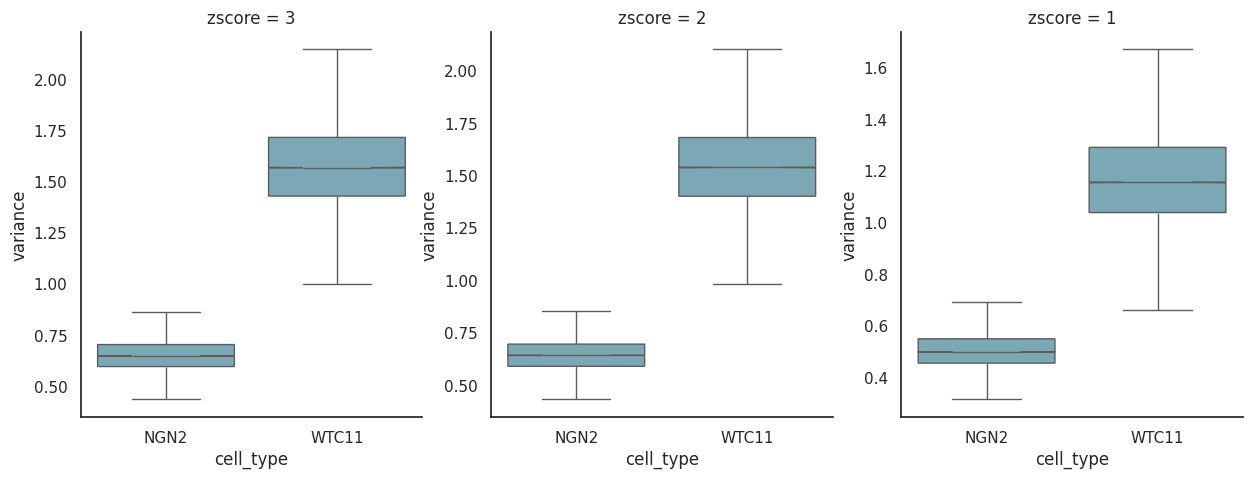

In [ ]:
cell_variance_box_plot([reshaped_celltyp_variance_z_3,
                        reshaped_celltyp_variance_z_2,
                        reshaped_celltyp_variance_z_1],
                       
                       ['zscore = 3', 'zscore = 2', 'zscore = 1'])

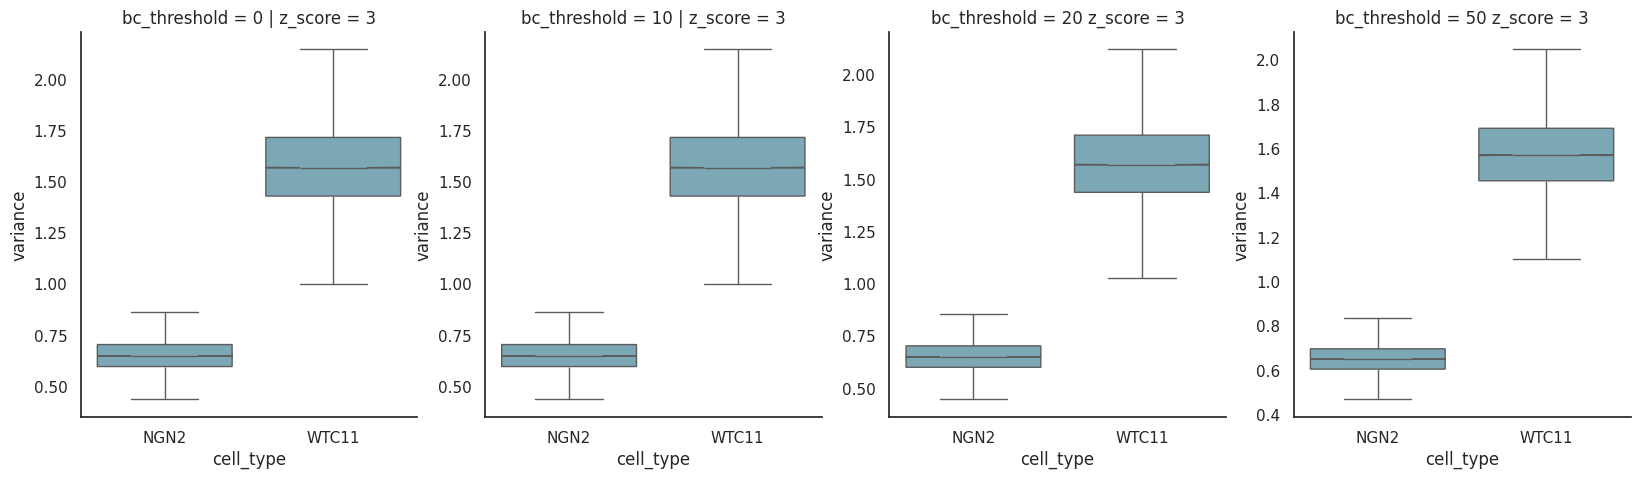

In [78]:
cell_variance_box_plot([reshaped_celltyp_variance_bc_0_z_3,
                        reshaped_celltyp_variance_bc_10_z_3,
                        reshaped_celltyp_variance_bc_20_z_3,
                        reshaped_celltyp_variance_bc_50_z_3],
                       
                       ['bc_threshold = 0 | z_score = 3','bc_threshold = 10 | z_score = 3', 'bc_threshold = 20 z_score = 3', 'bc_threshold = 50 z_score = 3'])

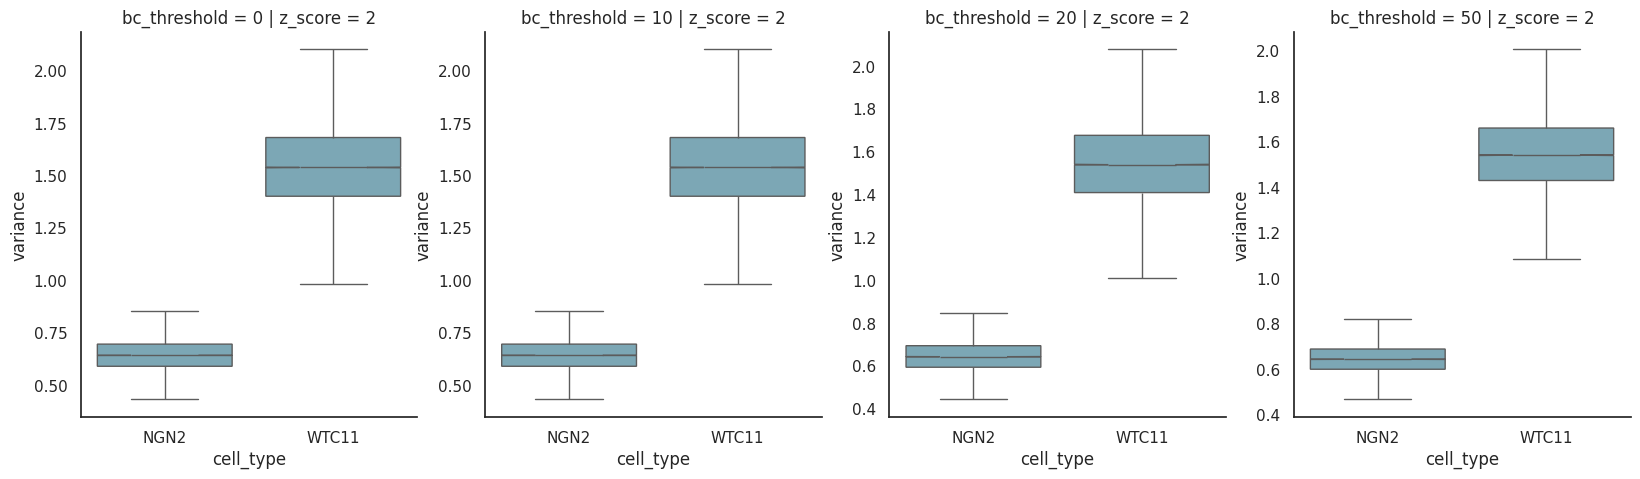

In [79]:
cell_variance_box_plot([reshaped_celltyp_variance_bc_0_z_2,
                        reshaped_celltyp_variance_bc_10_z_2,
                        reshaped_celltyp_variance_bc_20_z_2,
                        reshaped_celltyp_variance_bc_50_z_2],
                       
                       ['bc_threshold = 0 | z_score = 2','bc_threshold = 10 | z_score = 2', 'bc_threshold = 20 | z_score = 2', 'bc_threshold = 50 | z_score = 2'])

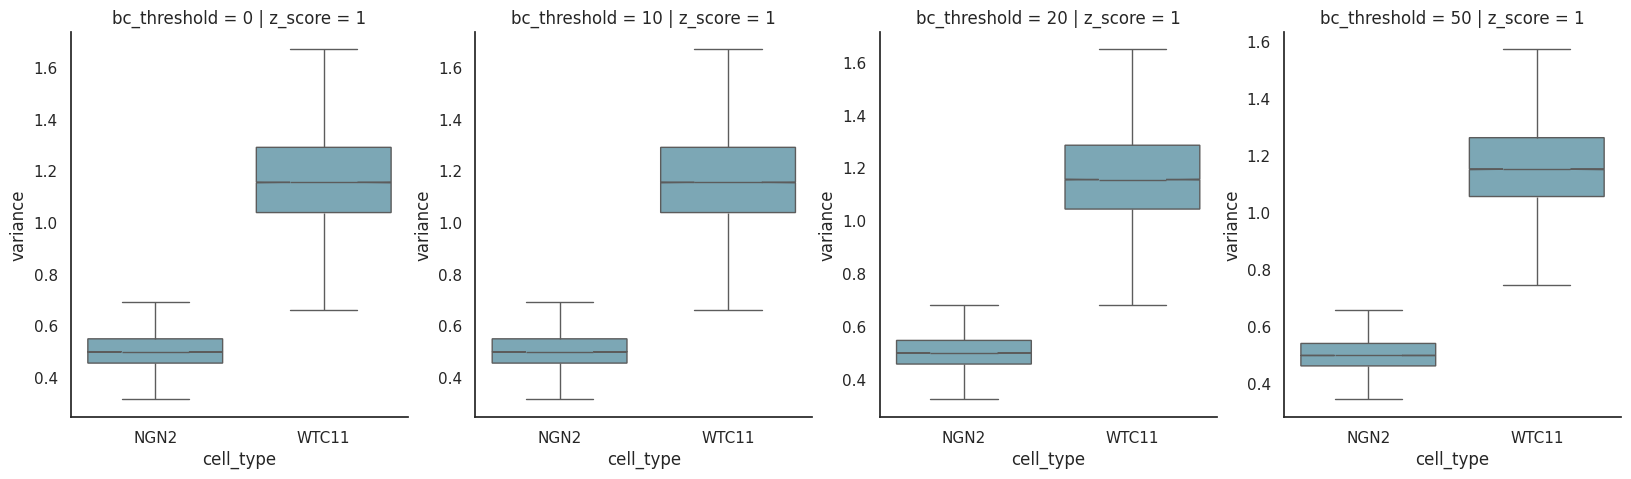

In [32]:
cell_variance_box_plot([reshaped_celltyp_variance_bc_0_z_1,
                        reshaped_celltyp_variance_bc_10_z_1,
                        reshaped_celltyp_variance_bc_20_z_1,
                        reshaped_celltyp_variance_bc_50_z_1],
                       
                       ['bc_threshold = 0 | z_score = 1','bc_threshold = 10 | z_score = 1', 'bc_threshold = 20 | z_score = 1', 'bc_threshold = 50 | z_score = 1'])

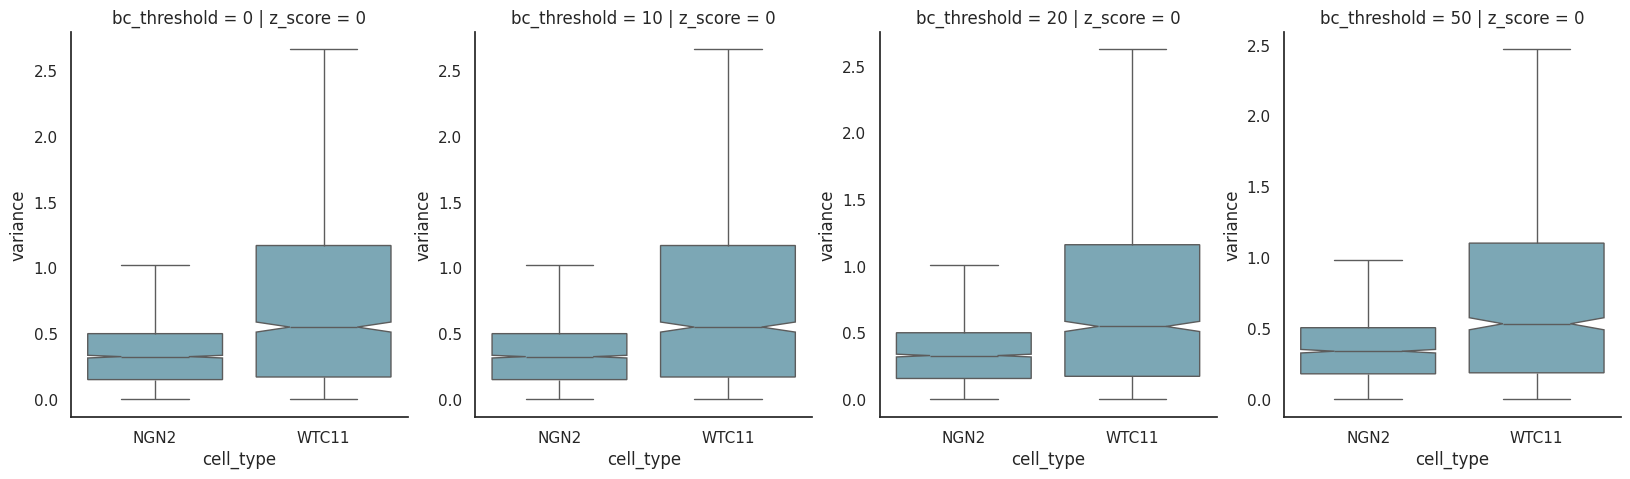

In [95]:
cell_variance_box_plot([reshaped_celltyp_variance_bc_0_z_0,
                        reshaped_celltyp_variance_bc_10_z_0,
                        reshaped_celltyp_variance_bc_20_z_0,
                        reshaped_celltyp_variance_bc_50_z_0],
                       
                       ['bc_threshold = 0 | z_score = 0','bc_threshold = 10 | z_score = 0', 'bc_threshold = 20 | z_score = 0', 'bc_threshold = 50 | z_score = 0'])

In [102]:
len(reshaped_celltyp_mean_bc_0_z_3) == len(reshaped_celltyp_mean_bc_0_z_0)

False

In [104]:
len(reshaped_celltyp_mean_bc_0_z_3)

155918

In [105]:
oligos_z3 = set(
    reshaped_celltyp_mean_bc_0_z_3["oligo_name"]
)

oligos_z0 = set(
    reshaped_celltyp_mean_bc_0_z_0["oligo_name"]
)

removed_in_z0 = oligos_z3 - oligos_z0

print(len(removed_in_z0))

14


In [54]:
reshaped_celltyp_variance_bc_0_z_1 = pd.read_table('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_0_z_1.tsv.gz')
reshaped_celltyp_variance_bc_10_z_1 = pd.read_table('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_10_z_1.tsv.gz')
reshaped_celltyp_variance_bc_20_z_1 = pd.read_table('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_20_z_1.tsv.gz')
reshaped_celltyp_variance_bc_50_z_1 = pd.read_table('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_50_z_1.tsv.gz')

In [37]:
reshaped_celltyp_variance_bc_0_z_1.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_0_z_1.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_10_z_1.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_10_z_1.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_20_z_1.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_20_z_1.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_50_z_1.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_50_z_1.tsv.gz',
                                          sep = '\t',
                                          index = False)

In [43]:
reshaped_celltyp_variance_bc_0_z_3.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_0_z_3.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_10_z_3.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_10_z_3.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_20_z_3.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_20_z_3.tsv.gz',
                                          sep = '\t',
                                          index = False)
reshaped_celltyp_variance_bc_50_z_3.to_csv('data/results/barcode_thresholds/reshaped_celltyp_variance_bc_50_z_3.tsv.gz',
                                          sep = '\t',
                                          index = False)

In [61]:
def calculate_common_non_outlier_bounds(
    data_table: pd.DataFrame
) -> tuple[float, float]:

    non_outlier_ranges = {}

    for cell_type, group in data_table.groupby("cell_type"):
        variance = group["variance"].dropna()

        q1 = variance.quantile(0.25)
        q3 = variance.quantile(0.75)
        iqr = q3 - q1

        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr

        non_outliers = variance.between(lower_fence, upper_fence)

        non_outlier_ranges[cell_type] = (
            variance[non_outliers].min(),
            variance[non_outliers].max()
        )

    lower_bound = max(
        interval[0] for interval in non_outlier_ranges.values()
    )

    upper_bound = min(
        interval[1] for interval in non_outlier_ranges.values()
    )

    return lower_bound, upper_bound

In [62]:
lower_bound, upper_bound = calculate_common_non_outlier_bounds(reshaped_celltyp_variance_bc_0_z_1)
lower_bound, upper_bound

(np.float64(0.66103566), np.float64(0.69107956))

In [77]:
similar_variance = reshaped_celltyp_variance_bc_0_z_1[reshaped_celltyp_variance_bc_0_z_1['variance'].between(lower_bound, upper_bound)].reset_index(drop = True)

In [78]:
len(similar_variance)

1422

In [73]:
variant_ref_alt_element_metrics_NGN2_WTC11 = pd.read_table('data/results/merge_elements/variant_ref_alt_element_metrics_NGN2_WTC11.tsv.gz')

In [74]:
variant_ref_alt_element_metrics_NGN2_WTC11.head()

,variant_id,logFC_NGN2,variant_effect_NGN2,adj.P.Val_NGN2,significant_NGN2,sig_category_NGN2,variant_effect_WTC11,logFC_WTC11,adj.P.Val_WTC11,significant_WTC11,...,dna_count_2_ALT_WTC11,dna_count_3_ALT_WTC11,rna_count_1_ALT_WTC11,rna_count_2_ALT_WTC11,rna_count_3_ALT_WTC11,unique_barcode_count_ALT_WTC11,label_ALT,effect_size_ALT_WTC11,norm_effect_size_ALT_WTC11,adj.P.Value_ALT_WTC11
0,C_positive_heart_CAD:ALT_rs1037169_rs1037169,-0.010908,NaN,0.987905,False,not_significant,NaN,NaN,NaN,NaN,...,353.0,332.0,671.0,884.0,952.0,53.0,C_positive_heart_CAD,0.094808,0.360180,1.0
1,C_positive_heart_CAD:ALT_rs1051338_rs1051338,-0.055394,-0.000419,0.882584,False,not_significant,-0.043954,-0.099785,0.932064,False,...,643.0,576.0,1167.0,1178.0,1379.0,129.0,C_positive_heart_CAD,-0.035234,0.005209,1.0
2,C_positive_heart_CAD:ALT_rs10750098_rs10750098,0.090207,NaN,0.905374,False,not_significant,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,C_positive_heart_CAD:ALT_rs10774625_rs10774625,0.220865,NaN,0.381383,False,not_significant,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,C_positive_heart_CAD:ALT_rs10811656_rs10811656,0.060657,NaN,0.900026,False,not_significant,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
selected_oligos = set(similar_variance["oligo_name"])
variant_qc = variant_ref_alt_element_metrics_NGN2_WTC11[variant_ref_alt_element_metrics_NGN2_WTC11['oligo_name_REF'].isin(selected_oligos)
                                                        & variant_ref_alt_element_metrics_NGN2_WTC11['oligo_name_ALT'].isin(selected_oligos)]

In [81]:
len(variant_qc)

6

Barcode outlier filtering reduces the overall variance, particularly at z-score = 1, but does not eliminate the variance difference between NGN2 and WTC11.